# GWAS Gene Annotation Mini Project

This project demonstrates how GWAS variants can be connected to nearby genes.

The analysis uses simulated GWAS results and simulated gene annotations to identify candidate genes near the strongest association signals.

This is an educational example and does not use real genomic coordinates or real biological conclusions.

In [1]:
import pandas as pd
import numpy as np

# Simulated GWAS results
gwas_data = {
    "SNP": ["rs2001", "rs2002", "rs2003", "rs2004", "rs2005",
            "rs2006", "rs2007", "rs2008", "rs2009", "rs2010"],
    "CHR": [1, 1, 2, 2, 3, 3, 4, 4, 5, 5],
    "BP": [105000, 250000, 410000, 620000, 830000,
           1040000, 1260000, 1480000, 1690000, 1910000],
    "P": [0.8, 0.25, 0.00000002, 0.6, 0.04,
          0.7, 0.000002, 0.9, 0.000000001, 0.15]
}

gwas_df = pd.DataFrame(gwas_data)

gwas_df

,SNP,CHR,BP,P
0,rs2001,1,105000,8.000000e-01
1,rs2002,1,250000,2.500000e-01
2,rs2003,2,410000,2.000000e-08
3,rs2004,2,620000,6.000000e-01
4,rs2005,3,830000,4.000000e-02
5,rs2006,3,1040000,7.000000e-01
6,rs2007,4,1260000,2.000000e-06
7,rs2008,4,1480000,9.000000e-01
8,rs2009,5,1690000,1.000000e-09
9,rs2010,5,1910000,1.500000e-01


In [2]:
# Create simulated gene annotations
gene_data = {
    "CHR": [1, 2, 3, 4, 5],
    "GENE": ["GENE_A", "GENE_B", "GENE_C", "GENE_D", "GENE_E"],
    "GENE_START": [100000, 400000, 820000, 1250000, 1680000],
    "GENE_END": [150000, 450000, 880000, 1300000, 1740000]
}

genes_df = pd.DataFrame(gene_data)

genes_df

,CHR,GENE,GENE_START,GENE_END
0,1,GENE_A,100000,150000
1,2,GENE_B,400000,450000
2,3,GENE_C,820000,880000
3,4,GENE_D,1250000,1300000
4,5,GENE_E,1680000,1740000


In [3]:
# Annotate each GWAS variant with an overlapping gene
annotated_df = gwas_df.merge(
    genes_df,
    on="CHR",
    how="left"
)

# Keep only variants located within a gene interval
annotated_df = annotated_df[
    (annotated_df["BP"] >= annotated_df["GENE_START"]) &
    (annotated_df["BP"] <= annotated_df["GENE_END"])
].copy()

# Rank annotated variants by p-value
annotated_df = annotated_df.sort_values("P")

annotated_df[
    ["SNP", "CHR", "BP", "P", "GENE"]
]

,SNP,CHR,BP,P,GENE
8,rs2009,5,1690000,1.000000e-09,GENE_E
2,rs2003,2,410000,2.000000e-08,GENE_B
6,rs2007,4,1260000,2.000000e-06,GENE_D
4,rs2005,3,830000,4.000000e-02,GENE_C
0,rs2001,1,105000,8.000000e-01,GENE_A


In [4]:
# Identify the strongest annotated associations
annotated_df["Genome_Wide_Significant"] = annotated_df["P"] < 5e-8

strongest_genes = annotated_df.sort_values("P")

strongest_genes[
    [
        "SNP",
        "CHR",
        "BP",
        "P",
        "GENE",
        "Genome_Wide_Significant"
    ]
]

,SNP,CHR,BP,P,GENE,Genome_Wide_Significant
8,rs2009,5,1690000,1.000000e-09,GENE_E,True
2,rs2003,2,410000,2.000000e-08,GENE_B,True
6,rs2007,4,1260000,2.000000e-06,GENE_D,False
4,rs2005,3,830000,4.000000e-02,GENE_C,False
0,rs2001,1,105000,8.000000e-01,GENE_A,False


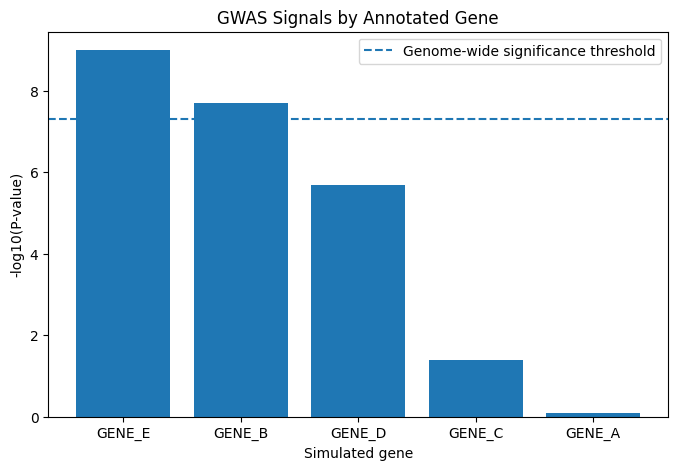

In [5]:
import matplotlib.pyplot as plt

# Create a bar chart of the strongest annotated signals
plot_df = annotated_df.sort_values("P").copy()

plt.figure(figsize=(8, 5))

plt.bar(
    plot_df["GENE"],
    -np.log10(plot_df["P"])
)

plt.axhline(
    -np.log10(5e-8),
    linestyle="--",
    label="Genome-wide significance threshold"
)

plt.xlabel("Simulated gene")
plt.ylabel("-log10(P-value)")
plt.title("GWAS Signals by Annotated Gene")
plt.legend()
plt.show()

## Interpretation

The strongest annotated signal is rs2009, which overlaps the simulated gene GENE_E and has a p-value of 1 × 10^-9.

The second strongest signal is rs2003, which overlaps GENE_B and has a p-value of 2 × 10^-8.

Both variants pass the conventional genome-wide significance threshold of 5 × 10^-8. rs2007 overlaps GENE_D but does not reach genome-wide significance.

These gene assignments are simulated and based only on whether a variant falls within a simulated gene interval. Real gene annotation would require reference genome coordinates and tools such as Ensembl VEP, ANNOVAR, or a similar annotation resource.